# 02 — EDA
Analisi esplorativa dei dati.

**Input:** `movies_cleaned.csv`, `collab_df.csv`

In [1]:
import ast
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from matplotlib.ticker import ScalarFormatter

warnings.filterwarnings('ignore')

PALETTE = ["#2D6A4F", "#40916C", "#52B788", "#74C69D", "#95D5B2",
           "#B7E4C7", "#D8F3DC", "#1B4332", "#081C15"]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"font.family": "DejaVu Sans", "figure.dpi": 100})

## 1. Caricamento

In [2]:
df = pd.read_csv('movies_cleaned.csv')
df["Stars_list"]    = df["Stars_list"].apply(ast.literal_eval)
df["Director_list"] = df["Director_list"].apply(ast.literal_eval)
df["Genre_list"]    = df["Genre_list"].apply(ast.literal_eval)

collab_df = pd.read_csv('collab_df.csv')

all_actors    = [a for lst in df["Stars_list"]    for a in lst]
all_directors = [d for lst in df["Director_list"] for d in lst]
all_genres    = [g for lst in df["Genre_list"]    for g in lst]

actor_counts    = Counter(all_actors)
director_counts = Counter(all_directors)
genre_counts    = Counter(all_genres)
actor_film_counts = Counter(all_actors)

print(f"Attori unici:    {len(set(all_actors)):,}")
print(f"Registi unici:   {len(set(all_directors)):,}")
print(f"Top 5 attori:    {actor_counts.most_common(5)}")
print(f"Top 5 registi:   {director_counts.most_common(5)}")

Attori unici:    13,210
Registi unici:   3,962
Top 5 attori:    [('Robert De Niro', 65), ('Nicolas Cage', 63), ('Samuel L. Jackson', 62), ('Bruce Willis', 55), ('Tom Hanks', 54)]
Top 5 registi:   [('Woody Allen', 40), ('Clint Eastwood', 33), ('Steven Spielberg', 30), ('Steven Soderbergh', 27), ('Ron Howard', 26)]


## 2. Panoramica dataset

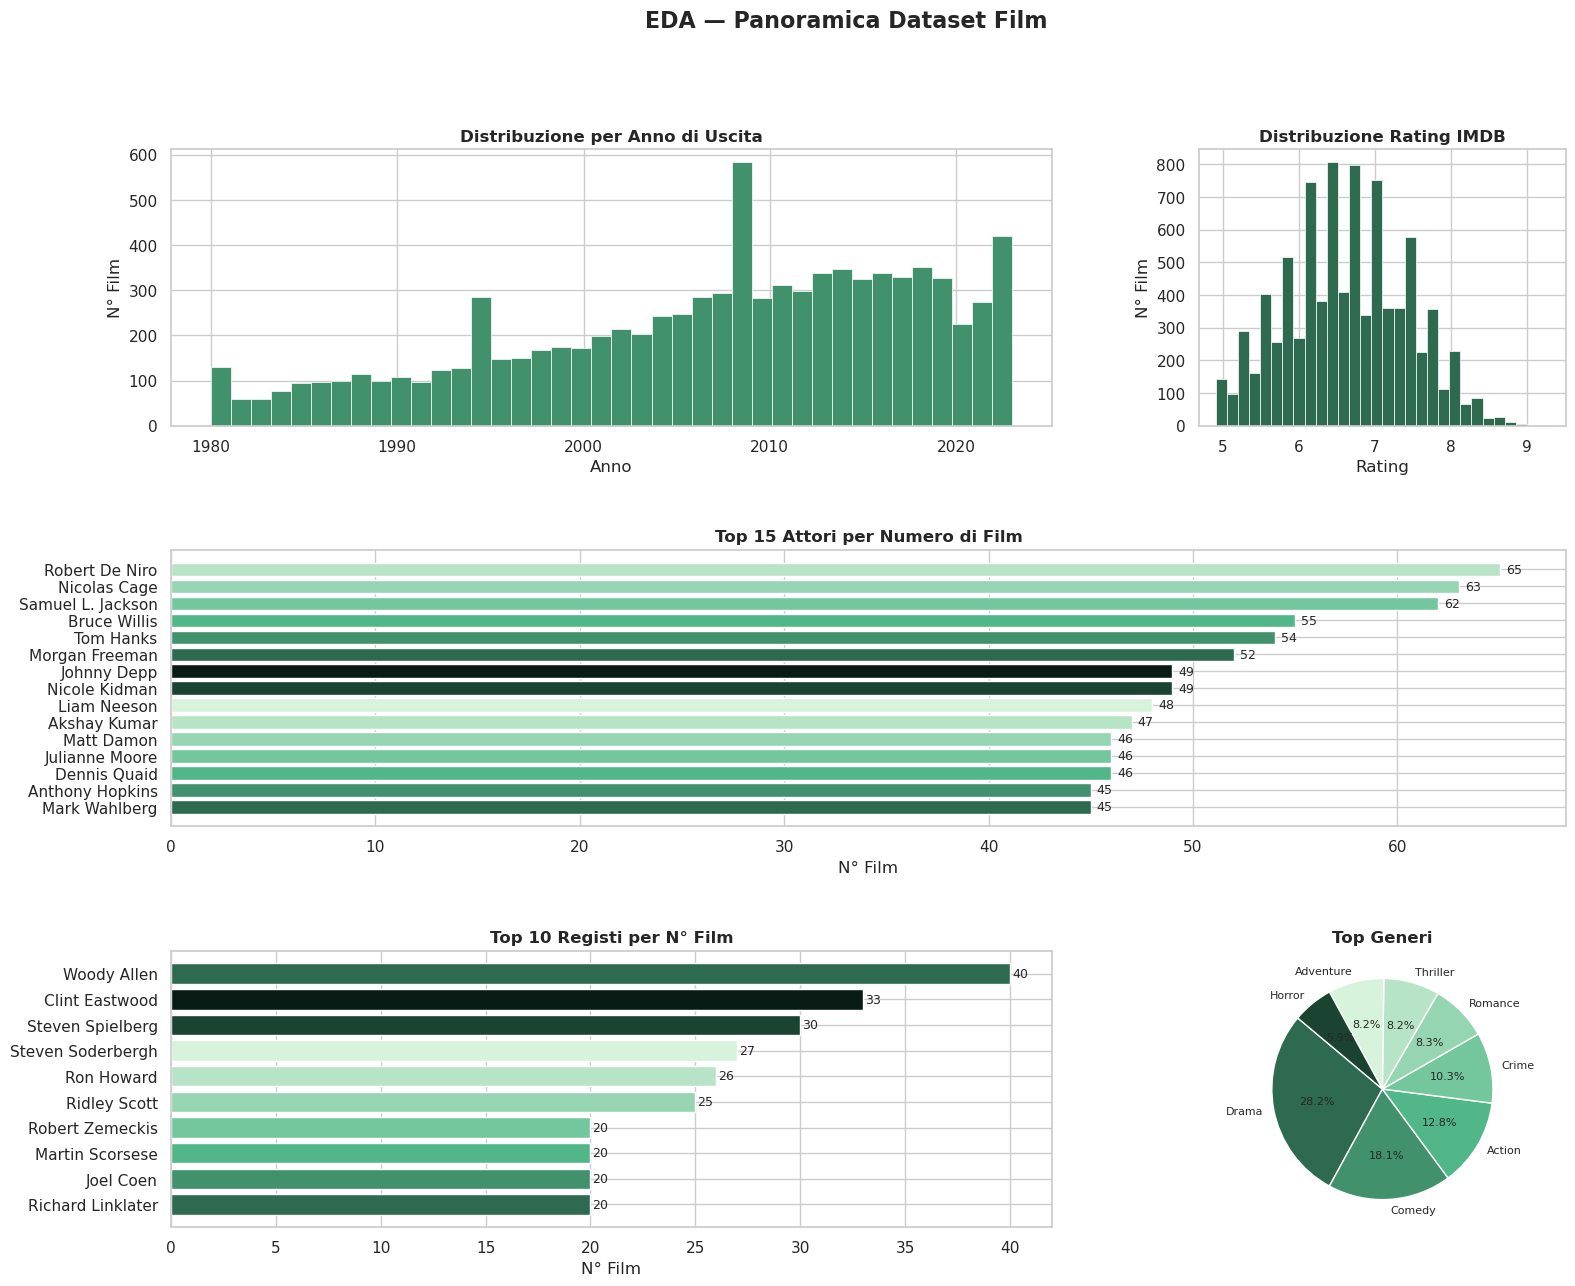

In [3]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle("EDA — Panoramica Dataset Film", fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.4)

ax1 = fig.add_subplot(gs[0, :2])
ax1.hist(df["Year of Release"].dropna(), bins=40,
         color=PALETTE[1], edgecolor="white", linewidth=0.5)
ax1.set_title("Distribuzione per Anno di Uscita", fontweight="bold")
ax1.set_xlabel("Anno"); ax1.set_ylabel("N° Film")

ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(df["Movie Rating"].dropna(), bins=30,
         color=PALETTE[0], edgecolor="white", linewidth=0.5)
ax2.set_title("Distribuzione Rating IMDB", fontweight="bold")
ax2.set_xlabel("Rating"); ax2.set_ylabel("N° Film")

ax3 = fig.add_subplot(gs[1, :])
top_actors = pd.Series(actor_counts).nlargest(15)
bars = ax3.barh(top_actors.index[::-1], top_actors.values[::-1],
                color=[PALETTE[i % len(PALETTE)] for i in range(15)])
ax3.set_title("Top 15 Attori per Numero di Film", fontweight="bold")
ax3.set_xlabel("N° Film")
for bar, val in zip(bars, top_actors.values[::-1]):
    ax3.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             str(val), va="center", fontsize=9)

ax4 = fig.add_subplot(gs[2, :2])
top_dirs = pd.Series(director_counts).nlargest(10)
bars2 = ax4.barh(top_dirs.index[::-1], top_dirs.values[::-1],
                 color=[PALETTE[i % len(PALETTE)] for i in range(10)])
ax4.set_title("Top 10 Registi per N° Film", fontweight="bold")
ax4.set_xlabel("N° Film")
for bar, val in zip(bars2, top_dirs.values[::-1]):
    ax4.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
             str(val), va="center", fontsize=9)

ax5 = fig.add_subplot(gs[2, 2])
top_genres = pd.Series(genre_counts).nlargest(8)
ax5.pie(top_genres.values, labels=top_genres.index,
        autopct="%1.1f%%", colors=PALETTE[:8],
        startangle=140, textprops={"fontsize": 8})
ax5.set_title("Top Generi", fontweight="bold")
plt.show()

## 3. Distribuzione film per attore

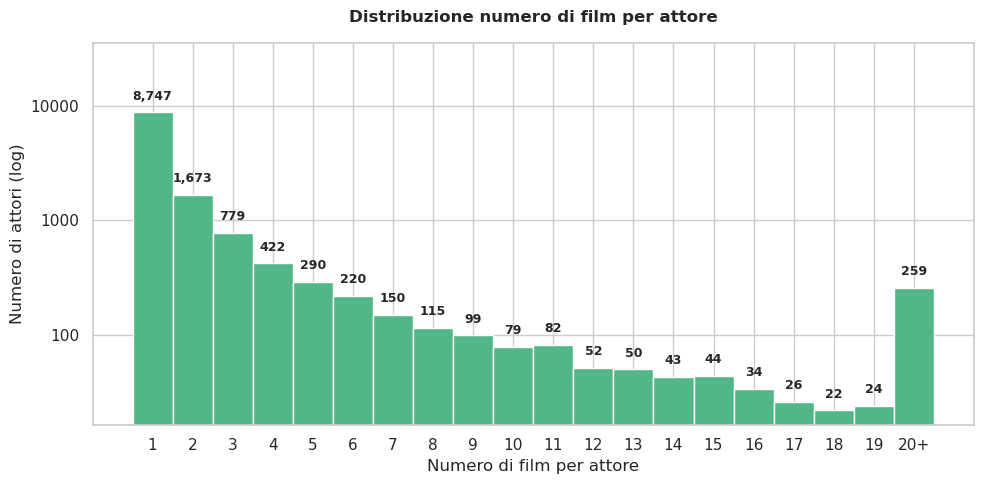

In [4]:
TRUNC = 20

def plot_actor_film_distribution(actor_film_counts, title, color, ax=None):
    """Distribuzione numero di film per attore (log scale).
    Valori > TRUNC aggregati nell'ultima barra per leggibilità."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
        standalone = True
    else:
        standalone = False

    film_counts_trunc = [min(c, TRUNC) for c in actor_film_counts.values()]
    n, bins, patches = ax.hist(
        film_counts_trunc, bins=range(1, TRUNC + 2),
        color=color, edgecolor="white", log=True, align="left"
    )
    for patch in patches:
        height = patch.get_height()
        if height > 0:
            ax.annotate(f'{int(height):,}',
                        xy=(patch.get_x() + patch.get_width() / 2, height),
                        xytext=(0, 7), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_ylim(top=ax.get_ylim()[1] * 3)
    ticks = list(range(1, TRUNC + 1))
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(x) if x < TRUNC else f"{TRUNC}+" for x in ticks])
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.get_major_formatter().set_scientific(False)
    ax.set_title(title, fontweight="bold", pad=15)
    ax.set_xlabel("Numero di film per attore")
    ax.set_ylabel("Numero di attori (log)")

    if standalone:
        plt.tight_layout()
        plt.show()

plot_actor_film_distribution(actor_film_counts, "Distribuzione numero di film per attore", PALETTE[2])

## 4. Distribuzione collaborazioni tra attori

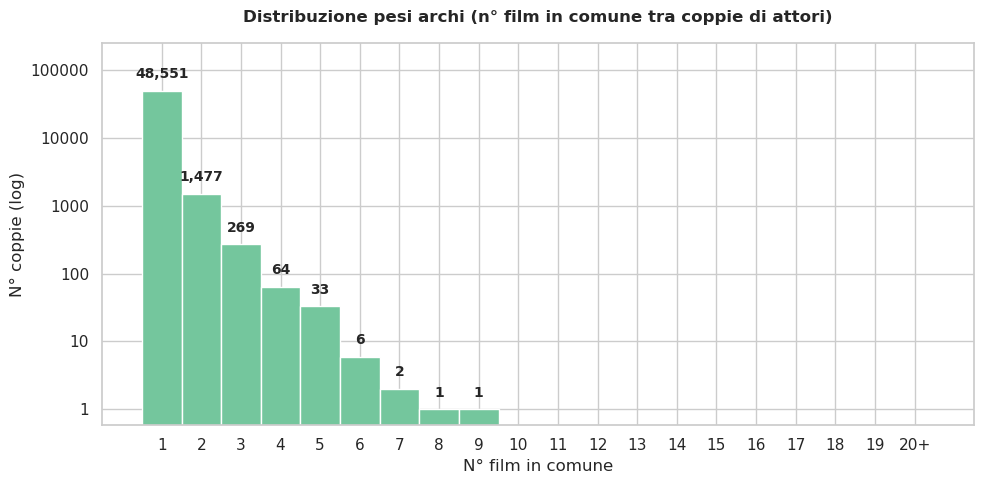

In [5]:
TRUNC_COLLAB = 20

def plot_weight_distribution(collab_data, title, color, ax=None):
    """Istogramma (log) distribuzione pesi archi. Valori > TRUNC_COLLAB aggregati."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
        standalone = True
    else:
        standalone = False

    weights_trunc = [min(w, TRUNC_COLLAB) for w in collab_data["weight"]]
    n, bins, patches = ax.hist(
        weights_trunc, bins=range(1, TRUNC_COLLAB + 2),
        color=color, edgecolor="white", log=True, align="left"
    )
    for patch in patches:
        height = patch.get_height()
        if height > 0:
            ax.annotate(f'{int(height):,}',
                        xy=(patch.get_x() + patch.get_width() / 2, height),
                        xytext=(0, 7), textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_ylim(top=ax.get_ylim()[1] * 3)
    ticks = list(range(1, TRUNC_COLLAB + 1))
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(x) if x < TRUNC_COLLAB else f"{TRUNC_COLLAB}+" for x in ticks])
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.get_major_formatter().set_scientific(False)
    ax.set_title(title, fontweight="bold", pad=15)
    ax.set_xlabel("N° film in comune")
    ax.set_ylabel("N° coppie (log)")

    if standalone:
        plt.tight_layout()
        plt.show()

plot_weight_distribution(collab_df, "Distribuzione pesi archi (n° film in comune tra coppie di attori)", PALETTE[3])